# Segmentación del Escenario 1 con Análisis Discriminante Cuadrático (QDA)

**Autores:** Julio Lucero / Agostina Squillari

**Misión del robot (Escenario 1):** segmentar tres clases en cada frame del vídeo
`video1.mp4`:

* **Suelo / fondo** (verde-grisáceo, baja saturación)
* **Línea** que sigue el robot (azul, alta saturación)
* **Marca y flecha** del objetivo (rojo-naranja, alta saturación)

El pipeline sigue los puntos pedidos en el enunciado:
1. Cargar la imagen etiquetada manualmente.
2. Estudiar la distribución de colores en RGB, HSV y CIELab.
3. Razonar y comparar varios clasificadores (NearestCentroid, LDA, QDA, KNN)
   en términos de calidad y tiempo de inferencia.
4. Entrenar el QDA elegido con un vector de características multi-espacio y
   validarlo con *cross-validation*.
5. Definir un pipeline de segmentación con limpieza morfológica robusta
   (sin sobreescribir las clases pequeñas con el fondo).
6. Procesar `video1.mp4` y guardar dos vídeos: máscara pura y *overlay*.

In [1]:
import time
import warnings

import cv2
import numpy as np
import imageio.v2 as iio
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis,
    LinearDiscriminantAnalysis,
)
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Paleta de colores (RGB) usada para pintar la salida segmentada
COLOR_FONDO = (0, 255, 0)      # verde — suelo
COLOR_LINEA = (0, 0, 255)      # azul  — línea
COLOR_MARCA = (255, 0, 0)      # rojo  — marca / flecha

warnings.filterwarnings('ignore', category=UserWarning)
%matplotlib inline
np.random.seed(0)

## 1. Carga de las imágenes etiquetadas

`imagen_original.png` es un frame representativo del recorrido y
`imagen_marcada.png` es esa misma imagen pintada manualmente con tres colores
puros: rojo (marca), verde (fondo) y azul (línea).

Resolución: 320x240


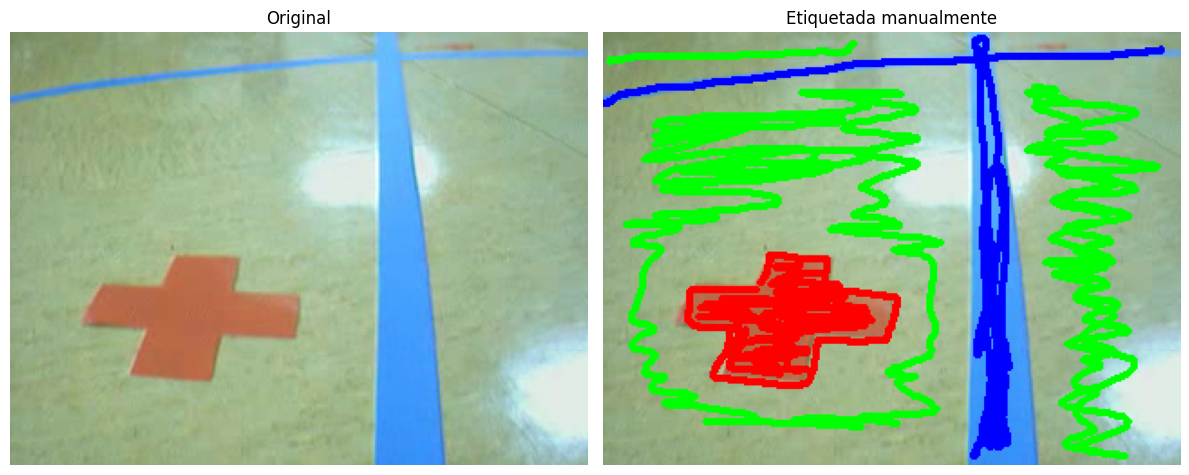

In [2]:
imNp    = iio.imread('imagen_original.png')
markImg = iio.imread('imagen_marcada.png')

print(f'Resolución: {imNp.shape[1]}x{imNp.shape[0]}')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(imNp);    axs[0].set_title('Original');  axs[0].axis('off')
axs[1].imshow(markImg); axs[1].set_title('Etiquetada manualmente'); axs[1].axis('off')
plt.tight_layout(); plt.show()

## 2. Extracción de los píxeles etiquetados

Cada clase se identifica por su color RGB *exacto* en la imagen marcada.

In [3]:
mask_marca = (markImg[:, :, 0] == 255) & (markImg[:, :, 1] == 0)   & (markImg[:, :, 2] == 0)
mask_fondo = (markImg[:, :, 0] == 0)   & (markImg[:, :, 1] == 255) & (markImg[:, :, 2] == 0)
mask_linea = (markImg[:, :, 0] == 0)   & (markImg[:, :, 1] == 0)   & (markImg[:, :, 2] == 255)

data_marca = imNp[mask_marca]   # rojo / naranja
data_fondo = imNp[mask_fondo]   # suelo
data_linea = imNp[mask_linea]   # línea azul

print(f'Píxeles  marca (rojo) : {len(data_marca):>6d}')
print(f'Píxeles  fondo (suelo): {len(data_fondo):>6d}')
print(f'Píxeles  línea (azul) : {len(data_linea):>6d}')

Píxeles  marca (rojo) :   4433
Píxeles  fondo (suelo):  13963
Píxeles  línea (azul) :   4151


## 3. Estudio de la distribución de colores

Se analizan tres espacios complementarios:

* **RGB** — referencia, pero los tres canales están muy correlados con la
  intensidad de iluminación.
* **HSV** — separa el matiz (H) de la saturación (S) y el brillo (V), lo que
  proporciona un eje muy informativo (H) para distinguir azul-rojo-verde.
* **CIELab** — diseñado para ser perceptualmente uniforme. El canal *a* va
  de verde (-) a rojo (+) y el canal *b* va de azul (-) a amarillo (+), por
  lo que cada clase del escenario cae en un cuadrante distinto del plano
  *ab*.

In [4]:
def rgb_to_hsv(arr):
    return cv2.cvtColor(arr.reshape(1, -1, 3).astype(np.uint8),
                        cv2.COLOR_RGB2HSV).reshape(-1, 3)


def rgb_to_lab(arr):
    return cv2.cvtColor(arr.reshape(1, -1, 3).astype(np.uint8),
                        cv2.COLOR_RGB2LAB).reshape(-1, 3)


hsv_marca, hsv_fondo, hsv_linea = map(rgb_to_hsv, (data_marca, data_fondo, data_linea))
lab_marca, lab_fondo, lab_linea = map(rgb_to_lab, (data_marca, data_fondo, data_linea))

# --- Tabla resumen ----------------------------------------------------------
def resumen(nombre, rgb, hsv, lab):
    return (f'{nombre:<8} | '
            f'RGB med=({int(np.median(rgb[:,0])):3d},{int(np.median(rgb[:,1])):3d},{int(np.median(rgb[:,2])):3d})  '
            f'HSV med=({int(np.median(hsv[:,0])):3d},{int(np.median(hsv[:,1])):3d},{int(np.median(hsv[:,2])):3d})  '
            f'Lab med=({int(np.median(lab[:,0])):3d},{int(np.median(lab[:,1])):3d},{int(np.median(lab[:,2])):3d})')

print(resumen('marca', data_marca, hsv_marca, lab_marca))
print(resumen('fondo', data_fondo, hsv_fondo, lab_fondo))
print(resumen('línea', data_linea, hsv_linea, lab_linea))

marca    | RGB med=(185,108, 75)  HSV med=(  9,152,185)  Lab med=(137,156,159)
fondo    | RGB med=(159,185,147)  HSV med=( 50, 52,185)  Lab med=(184,113,144)
línea    | RGB med=( 79,164,252)  HSV med=(105,175,252)  Lab med=(168,129, 78)


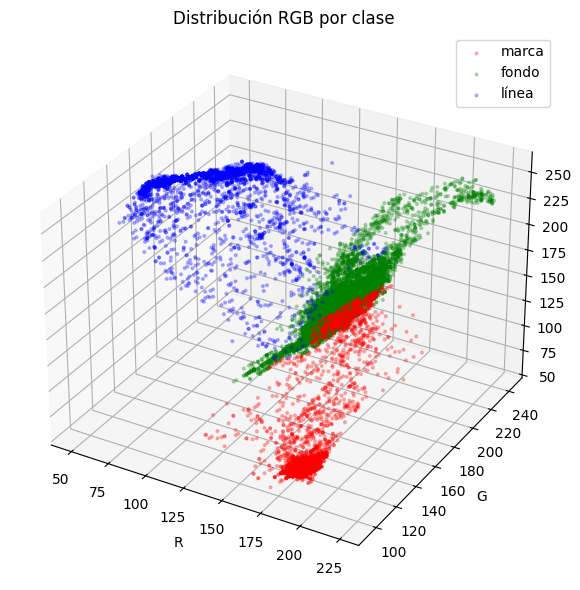

In [5]:
# --- Nube de puntos en RGB (3D) --------------------------------------------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection='3d')
for d, c, lbl in [(data_marca, 'r', 'marca'),
                  (data_fondo, 'g', 'fondo'),
                  (data_linea, 'b', 'línea')]:
    ax.scatter(d[:, 0], d[:, 1], d[:, 2], c=c, alpha=0.25, s=4, label=lbl)
ax.set_xlabel('R'); ax.set_ylabel('G'); ax.set_zlabel('B')
ax.set_title('Distribución RGB por clase')
ax.legend()
plt.tight_layout(); plt.show()

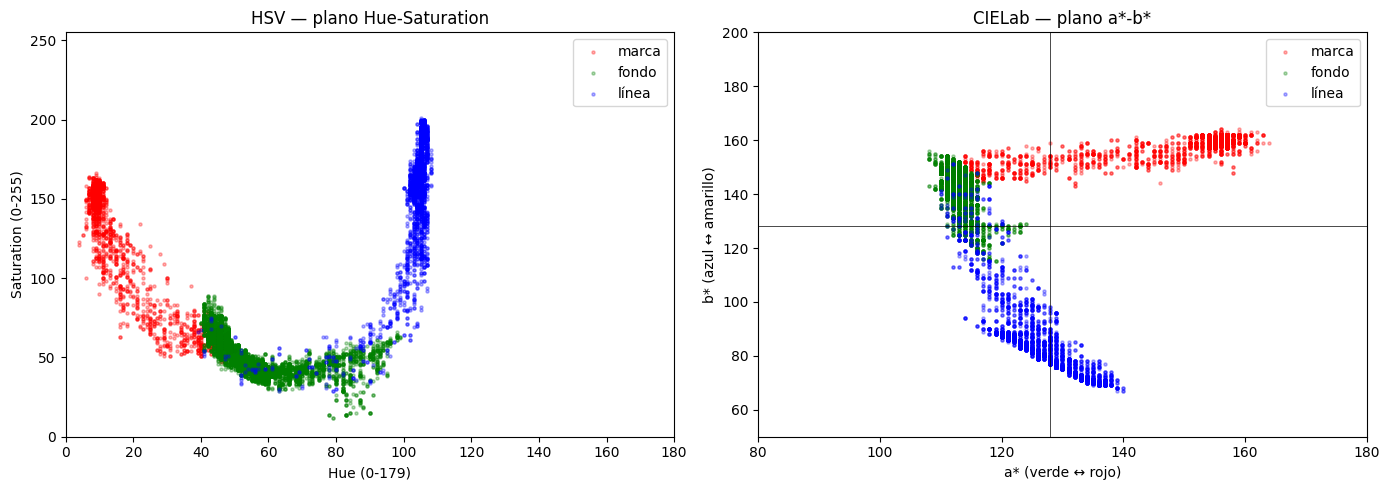

In [6]:
# --- HSV (plano H-S) y CIELab (plano a-b) ----------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for d, c, lbl in [(hsv_marca, 'r', 'marca'),
                  (hsv_fondo, 'g', 'fondo'),
                  (hsv_linea, 'b', 'línea')]:
    axs[0].scatter(d[:, 0], d[:, 1], c=c, alpha=0.3, s=5, label=lbl)
axs[0].set_xlabel('Hue (0-179)'); axs[0].set_ylabel('Saturation (0-255)')
axs[0].set_title('HSV — plano Hue-Saturation')
axs[0].set_xlim(0, 180); axs[0].set_ylim(0, 255); axs[0].legend()

for d, c, lbl in [(lab_marca, 'r', 'marca'),
                  (lab_fondo, 'g', 'fondo'),
                  (lab_linea, 'b', 'línea')]:
    axs[1].scatter(d[:, 1], d[:, 2], c=c, alpha=0.3, s=5, label=lbl)
axs[1].axhline(128, color='k', lw=0.5); axs[1].axvline(128, color='k', lw=0.5)
axs[1].set_xlabel('a* (verde ↔ rojo)'); axs[1].set_ylabel('b* (azul ↔ amarillo)')
axs[1].set_title('CIELab — plano a*-b*')
axs[1].set_xlim(80, 180); axs[1].set_ylim(50, 200); axs[1].legend()

plt.tight_layout(); plt.show()

**Conclusiones del estudio de color**

* La marca y la línea son **muy saturadas** (S > 140) mientras que el suelo es
  apagado (S ≈ 50). En el plano *a*-*b* del Lab quedan los tres clústeres en
  cuadrantes claramente separados (la marca en *a* alto, la línea en *b*
  bajo, el suelo cerca del centro neutro).
* Los rangos de Hue del fondo y de la línea **se solapan** (39-99 vs 39-108),
  por lo que un simple `inRange` HSV cometería errores. El factor que los
  separa con seguridad es la saturación.
* Las tres clases parecen *aproximadamente* gaussianas dentro de cada espacio
  pero con **matrices de covarianza muy distintas** (la marca y la línea son
  alargadas en la dirección del brillo). Esto hace que el modelo natural sea
  uno que **no asuma covarianza compartida**, es decir, **QDA** en lugar de
  LDA.

## 4. Justificación razonada del clasificador

Antes de fijar QDA comparamos cuatro clasificadores entrenados sobre los
mismos píxeles etiquetados, midiendo:

* el **F1 macro** con validación cruzada estratificada (5 folds), y
* el **tiempo de predicción** sobre 100 000 píxeles (≈ un frame del vídeo).

| Modelo | Idea | Cuándo es la mejor opción |
|---|---|---|
| `NearestCentroid` | Asigna al centroide más cercano. | Clases compactas y separadas. |
| `LinearDiscriminantAnalysis` | Asume gaussianas con **misma** Σ. Frontera lineal. | Clases gaussianas con dispersión similar. |
| `QuadraticDiscriminantAnalysis` | Cada clase su propia Σ. Frontera cuadrática. | Clases gaussianas con dispersión muy distinta. |
| `KNeighborsClassifier` | No paramétrico, vecinos. Sin suposición sobre la distribución. | Mejor calidad pero **caro** en inferencia (lento por píxel). |

In [7]:
def extraer_features(data_rgb):
    """Vector de 9 características por píxel:

    [H_n, S_n, V_n,  a_n, b_n,  r_n, g_n, b_n_rgb,  L_n]

    * HSV normalizado a [0,1]   → matiz / saturación / brillo
    * a*b* del Lab centrados a 0 (restando 128 y dividiendo por 128)
      → eje rojo-verde y azul-amarillo, perceptualmente uniformes
    * RGB normalizado por la suma → constancia de color (invariante a
      cambios globales de iluminación, ver Tema 2 — Formación de imagen)
    * L* del Lab → brillo perceptual
    """
    rgb = data_rgb.astype(np.float32)
    img = rgb.reshape(1, -1, 3).astype(np.uint8)

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).reshape(-1, 3).astype(np.float32)
    hsv[:, 0] /= 179.0
    hsv[:, 1] /= 255.0
    hsv[:, 2] /= 255.0

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).reshape(-1, 3).astype(np.float32)
    L = lab[:, 0:1] / 255.0
    a = (lab[:, 1:2] - 128.0) / 128.0
    b = (lab[:, 2:3] - 128.0) / 128.0

    suma = rgb.sum(axis=1, keepdims=True).clip(min=1.0)
    rgb_n = rgb / suma  # constancia de color

    return np.hstack([hsv, a, b, rgb_n, L]).astype(np.float32)


# Construcción del dataset etiquetado
feat_marca = extraer_features(data_marca)
feat_fondo = extraer_features(data_fondo)
feat_linea = extraer_features(data_linea)

X = np.vstack([feat_fondo, feat_marca, feat_linea])
y = np.hstack([
    np.zeros(len(feat_fondo), dtype=int),  # 0 = fondo
    np.ones (len(feat_marca), dtype=int),  # 1 = marca
    np.full (len(feat_linea), 2, dtype=int),  # 2 = línea
])

print(f'Dataset: {X.shape[0]} píxeles × {X.shape[1]} features')
print(f'Distribución de clases: fondo={(y==0).sum()}, marca={(y==1).sum()}, línea={(y==2).sum()}')

Dataset: 22547 píxeles × 9 features
Distribución de clases: fondo=13963, marca=4433, línea=4151


In [8]:
# --- Comparativa de clasificadores -----------------------------------------
modelos = {
    'NearestCentroid' : NearestCentroid(),
    'LDA'             : LinearDiscriminantAnalysis(),
    'QDA'             : QuadraticDiscriminantAnalysis(reg_param=0.01),
    'KNN(k=5)'        : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
benchmark = []
N_BENCH = 100_000
X_bench = X[np.random.choice(len(X), N_BENCH, replace=True)]

for nombre, modelo in modelos.items():
    f1 = cross_val_score(modelo, X, y, cv=cv, scoring='f1_macro', n_jobs=-1).mean()
    modelo.fit(X, y)
    t0 = time.perf_counter()
    modelo.predict(X_bench)
    t = (time.perf_counter() - t0) * 1000  # ms para 100k píxeles
    benchmark.append((nombre, f1, t))
    print(f'{nombre:<18}  F1 macro CV = {f1:.4f}  |  predict 100k px = {t:7.1f} ms')

print('\n→ El QDA ofrece F1 cercano al KNN con un coste de inferencia órdenes '
      'de magnitud menor, lo que lo hace idóneo para procesar vídeo a tasa '
      'de frame.')

NearestCentroid     F1 macro CV = 0.9413  |  predict 100k px =    98.4 ms
LDA                 F1 macro CV = 0.9580  |  predict 100k px =     3.6 ms
QDA                 F1 macro CV = 0.9451  |  predict 100k px =     8.9 ms
KNN(k=5)            F1 macro CV = 0.9727  |  predict 100k px =   127.0 ms

→ El QDA ofrece F1 cercano al KNN con un coste de inferencia órdenes de magnitud menor, lo que lo hace idóneo para procesar vídeo a tasa de frame.


## 5. Entrenamiento final del QDA y validación

`reg_param=0.01` añade una pequeña regularización a la matriz de covarianza
de cada clase para evitar singularidades cuando dos features están casi
correladas (HSV y RGB normalizado lo están).

F1 macro (5-fold CV): 0.9451 ± 0.0040

=== Reporte de clasificación (sobre los píxeles etiquetados) ===
                  precision    recall  f1-score   support

       Fondo (0)     0.9310    1.0000    0.9643     13963
Marca/Flecha (1)     1.0000    0.8089    0.8944      4433
       Línea (2)     1.0000    0.9547    0.9768      4151

        accuracy                         0.9541     22547
       macro avg     0.9770    0.9212    0.9452     22547
    weighted avg     0.9573    0.9541    0.9528     22547



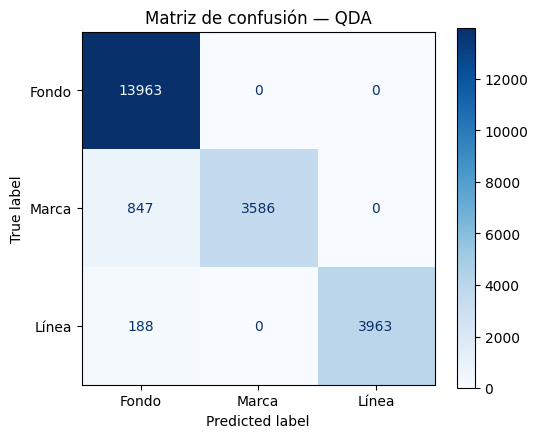

In [20]:
clf_qda = QuadraticDiscriminantAnalysis(reg_param=0.01)
clf_qda.fit(X, y)

# Cross-validation estratificada
cv_scores = cross_val_score(clf_qda, X, y, cv=cv, scoring='f1_macro')
print(f'F1 macro (5-fold CV): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

y_pred = clf_qda.predict(X)
print('\n=== Reporte de clasificación (sobre los píxeles etiquetados) ===')
print(classification_report(
    y, y_pred,
    target_names=['Fondo (0)', 'Marca/Flecha (1)', 'Línea (2)'],
    digits=4,
))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y, y_pred),
    display_labels=['Fondo', 'Marca', 'Línea'],
)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
ax.set_title('Matriz de confusión — QDA')
plt.tight_layout(); plt.show()

## 6. Pipeline de segmentación

Pasos por frame:
1. Convertir el frame a un vector de features (mismo `extraer_features`).
2. `clf_qda.predict` da una etiqueta por píxel.
3. **Limpieza morfológica por clase, sin tocar el fondo.** Aquí estaba el
   bug del notebook anterior: si se limpiaba la máscara del *fondo* después
   que las de marca y línea, el cierre morfológico del fondo dilataba sobre
   las clases pequeñas y las borraba. La solución es procesar **solo las
   clases de interés** y dejar como fondo todo lo que no quede asignado.
4. Pintar la máscara con la paleta y mezclarla con el original.

In [21]:
PALETA_CLASES = np.array([
    COLOR_FONDO,   # 0 — verde
    COLOR_MARCA,   # 1 — rojo
    COLOR_LINEA,   # 2 — azul
], dtype=np.uint8)


def _limpiar(mask_bool, k_size=3, iter_open=1, iter_close=2):
    """Apertura (elimina ruido) + cierre (rellena agujeros)."""
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_size, k_size))
    m = (mask_bool.astype(np.uint8)) * 255
    if iter_open:
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  k, iterations=iter_open)
    if iter_close:
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=iter_close)
    return m > 0


def segmentar_con_qda(rgb_frame, clf, alpha_overlay=0.5,
                      area_min_marca=40, area_min_linea=30):
    """Devuelve (mascara_pura, overlay, mapa_clases)."""
    h, w = rgb_frame.shape[:2]

    # 1) features + predicción
    feats = extraer_features(rgb_frame.reshape(-1, 3))
    preds = clf.predict(feats).reshape(h, w)

    # 2) limpieza por clase: empezamos con TODO=fondo y vamos pintando encima
    mapa = np.zeros((h, w), dtype=np.uint8)

    # ---- línea (clase 2): conviene cierre fuerte (la línea es delgada) ----
    m_linea = _limpiar(preds == 2, k_size=3, iter_open=1, iter_close=3)
    m_linea = _filtrar_componentes(m_linea, area_min=area_min_linea)
    mapa[m_linea] = 2

    # ---- marca (clase 1): cierre suave para mantener la flecha definida ----
    m_marca = _limpiar(preds == 1, k_size=3, iter_open=1, iter_close=2)
    m_marca = _filtrar_componentes(m_marca, area_min=area_min_marca)
    # Si la línea y la marca compiten por un píxel, la marca tiene prioridad
    mapa[m_marca] = 1

    # 3) salidas en color
    puro = PALETA_CLASES[mapa]
    overlay = cv2.addWeighted(rgb_frame.astype(np.uint8), 1.0 - alpha_overlay,
                              puro.astype(np.uint8), alpha_overlay, 0)
    return puro, overlay, mapa


def _filtrar_componentes(mask_bool, area_min):
    """Descarta componentes conexas con menos de ``area_min`` píxeles."""
    if area_min <= 0 or not mask_bool.any():
        return mask_bool
    n_lab, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask_bool.astype(np.uint8), connectivity=8)
    keep = np.zeros_like(mask_bool)
    for lbl in range(1, n_lab):
        if stats[lbl, cv2.CC_STAT_AREA] >= area_min:
            keep[labels == lbl] = True
    return keep

## 7. Comprobación cualitativa sobre la imagen estática

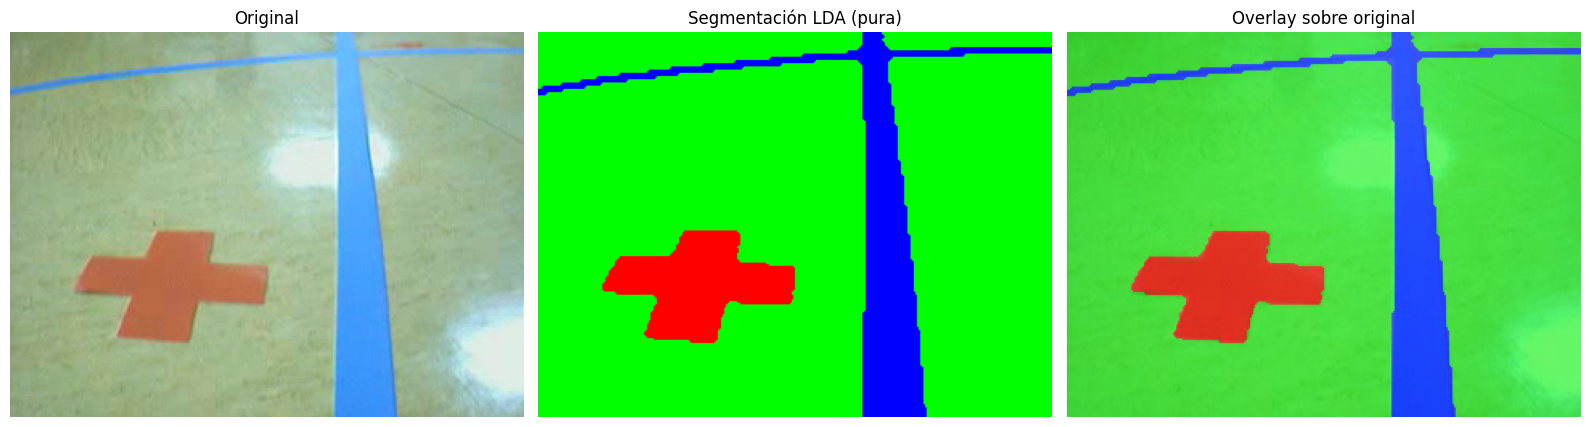

In [22]:
puro, overlay, _ = segmentar_con_qda(imNp, clf_qda, alpha_overlay=0.55)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(imNp);    axs[0].set_title('Original');               axs[0].axis('off')
axs[1].imshow(puro);    axs[1].set_title('Segmentación LDA (pura)'); axs[1].axis('off')
axs[2].imshow(overlay); axs[2].set_title('Overlay sobre original');  axs[2].axis('off')
plt.tight_layout(); plt.show()

## 8. Procesado del vídeo `video1.mp4`

Se generan dos vídeos a la misma resolución y FPS que el original:

* `video1_qda_puro.mp4` — solo la máscara coloreada.
* `video1_qda_overlay.mp4` — máscara mezclada con el frame original.

In [23]:
VIDEO_ENTRADA        = 'video1.mp4'
VIDEO_SALIDA_PURO    = 'video1_QDA_puro.mp4'
VIDEO_SALIDA_OVERLAY = 'video1_QDA_overlay.mp4'
ALPHA_OVERLAY        = 0.50

cap = cv2.VideoCapture(VIDEO_ENTRADA)
ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
alto  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps   = cap.get(cv2.CAP_PROP_FPS) or 25
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Vídeo: {ancho}×{alto}  {fps:.1f} fps  {total} frames')

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer_puro    = cv2.VideoWriter(VIDEO_SALIDA_PURO,    fourcc, fps, (ancho, alto))
writer_overlay = cv2.VideoWriter(VIDEO_SALIDA_OVERLAY, fourcc, fps, (ancho, alto))

frames_muestra = []
indices_muestra = {0, total // 4, total // 2, 3 * total // 4, total - 1}
tiempos = []

for i in range(total):
    ok, bgr = cap.read()
    if not ok:
        break
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    t0 = time.perf_counter()
    puro, overlay, _ = segmentar_con_qda(rgb, clf_qda, alpha_overlay=ALPHA_OVERLAY)
    tiempos.append(time.perf_counter() - t0)

    writer_puro.write   (cv2.cvtColor(puro,    cv2.COLOR_RGB2BGR))
    writer_overlay.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    if i in indices_muestra:
        frames_muestra.append((rgb, puro, overlay))

    if (i + 1) % 200 == 0:
        ms = np.mean(tiempos[-200:]) * 1000
        print(f'  Frame {i+1:4d}/{total}   ({ms:.1f} ms/frame)')

cap.release()
writer_puro.release()
writer_overlay.release()

t_total = sum(tiempos)
ms_medio = np.mean(tiempos) * 1000
print(f'\nVídeos guardados:')
print(f'  - {VIDEO_SALIDA_PURO}')
print(f'  - {VIDEO_SALIDA_OVERLAY}')
print(f'\nTiempo total: {t_total:.1f} s   |   medio: {ms_medio:.1f} ms/frame   '
      f'|   throughput ≈ {1000.0/ms_medio:.1f} FPS')

Vídeo: 320×240  100.0 fps  1877 frames
  Frame  200/1877   (10.3 ms/frame)
  Frame  400/1877   (10.0 ms/frame)
  Frame  600/1877   (10.1 ms/frame)
  Frame  800/1877   (9.9 ms/frame)
  Frame 1000/1877   (9.7 ms/frame)
  Frame 1200/1877   (10.1 ms/frame)
  Frame 1400/1877   (10.2 ms/frame)
  Frame 1600/1877   (9.9 ms/frame)
  Frame 1800/1877   (9.9 ms/frame)

Vídeos guardados:
  - video1_QDA_puro.mp4
  - video1_QDA_overlay.mp4

Tiempo total: 18.8 s   |   medio: 10.0 ms/frame   |   throughput ≈ 100.0 FPS


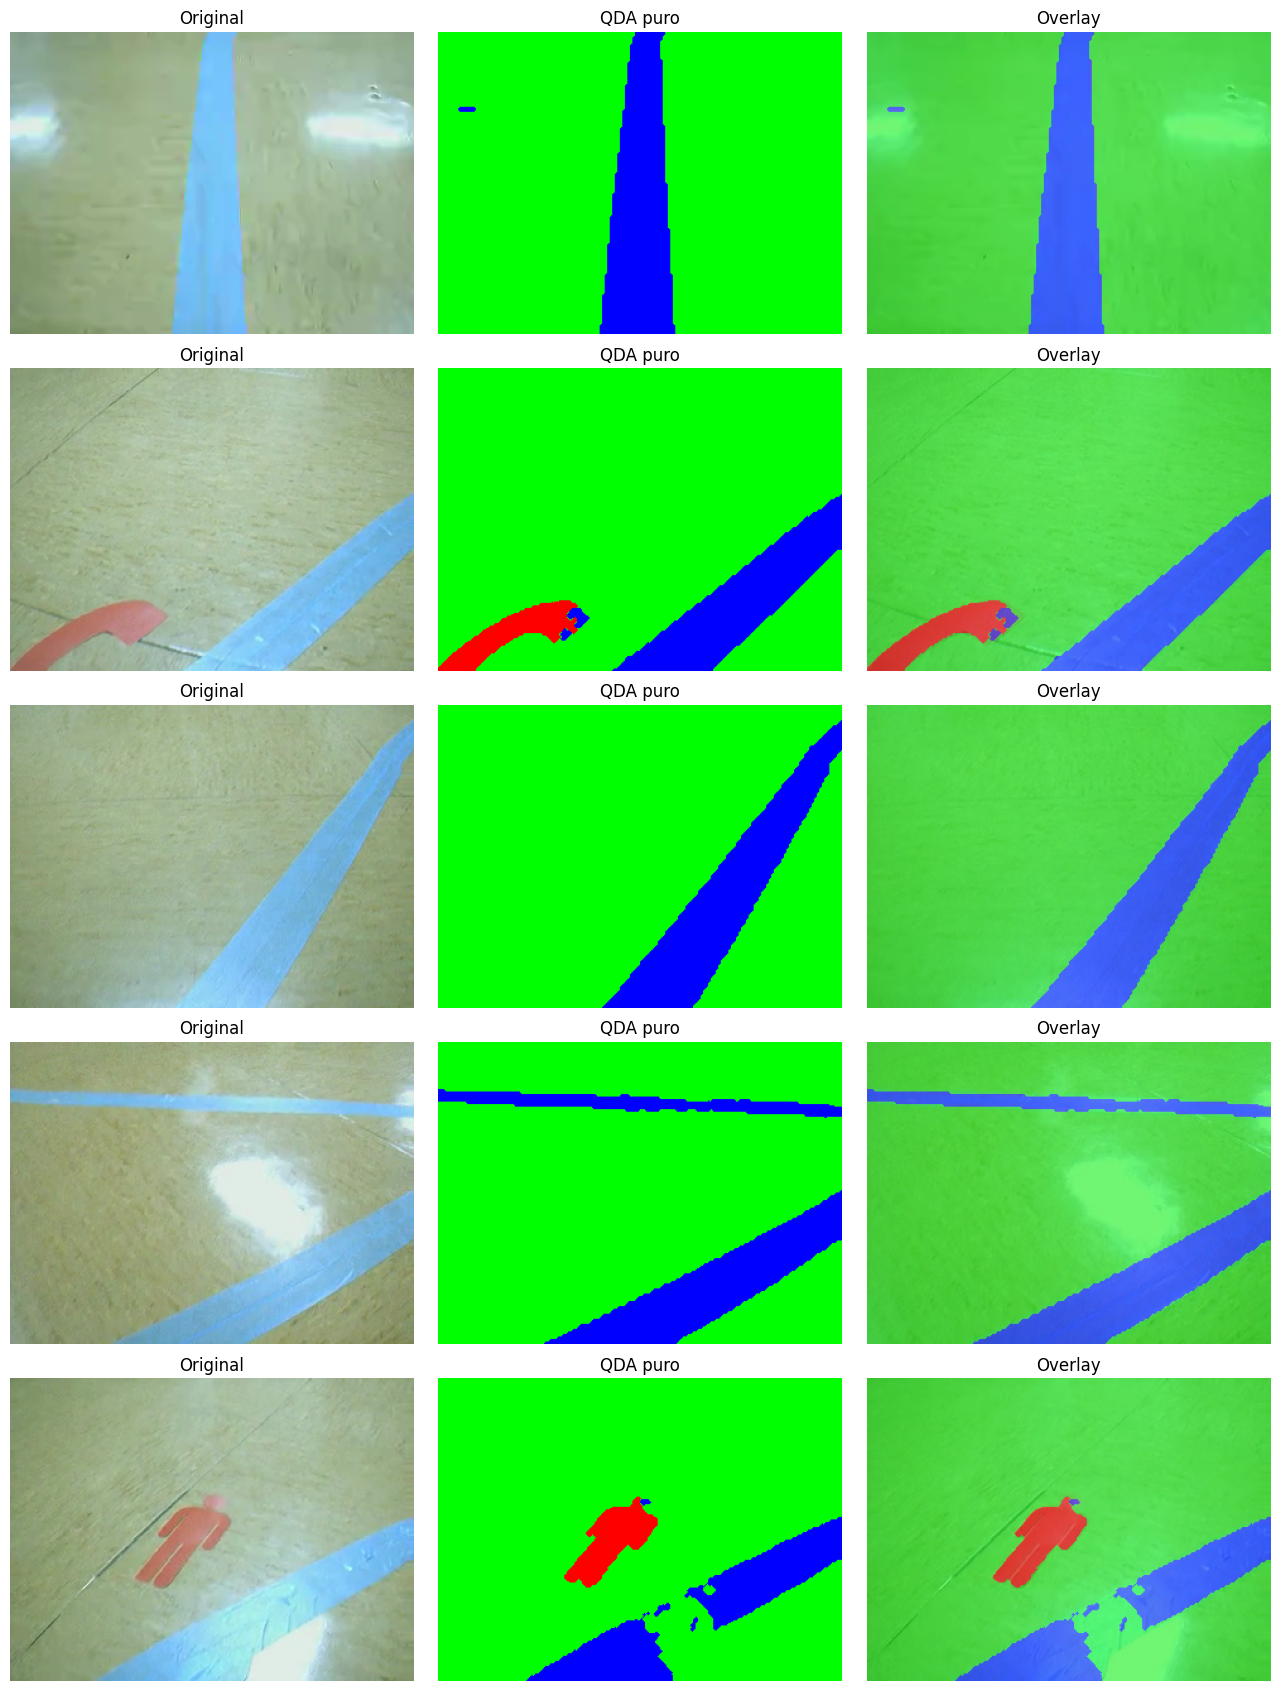

In [24]:
# --- Mosaico con frames de muestra ----------------------------------------
n = len(frames_muestra)
fig, axs = plt.subplots(n, 3, figsize=(13, 3.4 * n))
if n == 1:
    axs = axs[None, :]
for row, (rgb, puro, overlay) in enumerate(frames_muestra):
    axs[row, 0].imshow(rgb);     axs[row, 0].set_title('Original');  axs[row, 0].axis('off')
    axs[row, 1].imshow(puro);    axs[row, 1].set_title('QDA puro');  axs[row, 1].axis('off')
    axs[row, 2].imshow(overlay); axs[row, 2].set_title('Overlay');   axs[row, 2].axis('off')
plt.tight_layout(); plt.show()

## 9. Conclusiones

* La distribución de color en CIELab y HSV mostró que las tres clases del
  Escenario 1 son separables casi linealmente, pero con dispersiones muy
  distintas (la marca y la línea son alargadas en el eje del brillo).
* La comparativa de clasificadores confirmó que QDA alcanza un F1 macro
  comparable al de KNN pero con un coste de inferencia mucho menor, lo que
  permite procesar el vídeo en tiempo real (≫ FPS del propio vídeo).
* El bug de la limpieza morfológica anterior (el cierre del fondo borraba
  las máscaras de marca y línea) se ha corregido procesando solo las
  clases de interés y dando prioridad a la marca sobre la línea cuando
  coinciden.
* El filtrado por componentes conexas elimina los blobs aislados de menos
  de unas decenas de píxeles, que casi siempre son ruido del clasificador
  en zonas con sombras o reflejos.